Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520

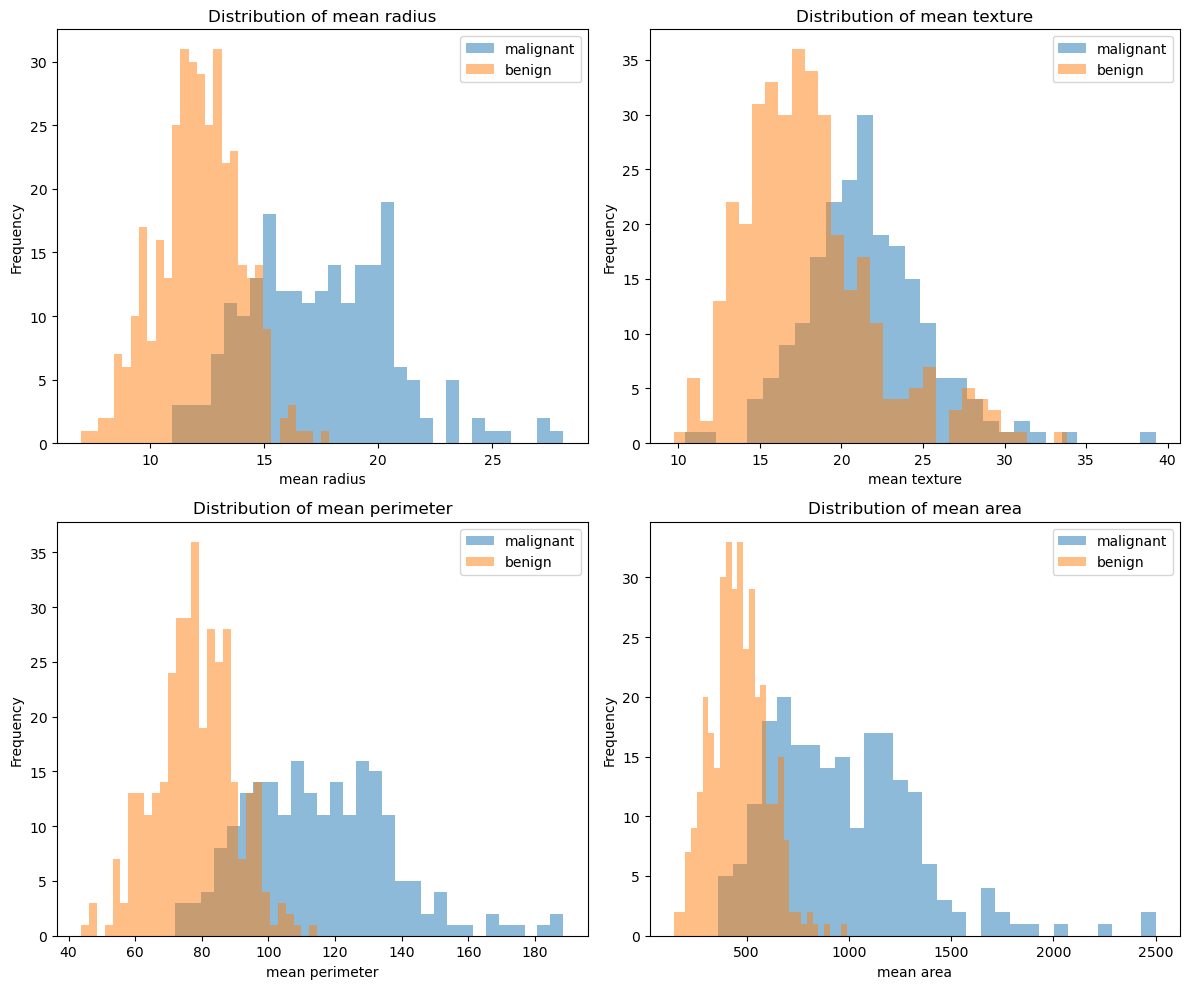


Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64

KNN classifier trained successfully.
Number of neighbors: 5

Training predictions: 455
Test predictions: 114

SAMPLE PREDICTIONS
    Actual  Predicted  Correct
0        0          0     True
1        1          1     True
2        0          0     True
3        1          0    False
4        0          0     True
5        1          1     True
6        1          1     True
7        0          0     True
8        0          0     True
9        0          0     True
10       1          1     True
11       0          0     True
12       1          1     True
13       0          0     True
14       0          0     True
15       1          1     True
16       1         

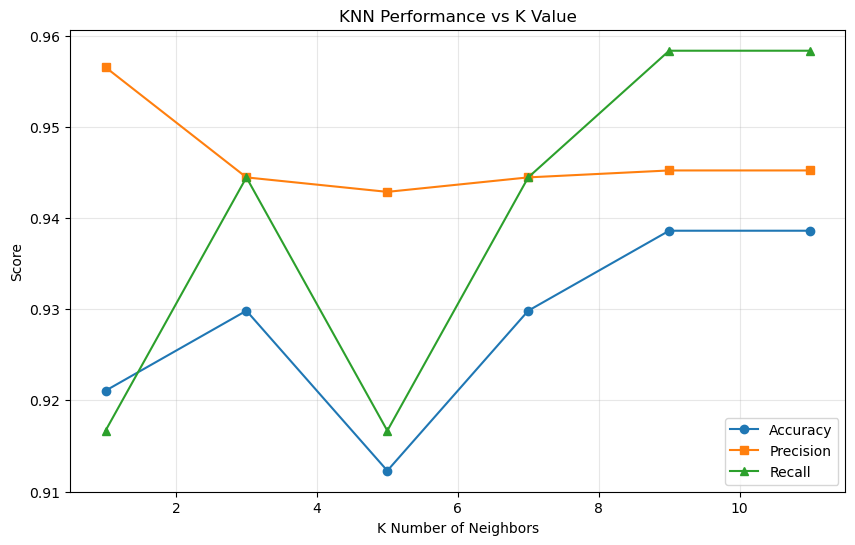


FINAL OBSERVATIONS

The KNN model achieved strong performance on the breast cancer dataset.
The model performed well because the dataset contains numeric features that show clear differences between the two classes.
Changing the K value affected accuracy, precision, and recall, showing that model performance depends on parameter selection.



In [1]:
"""
Breast Cancer Prediction with KNN
Author: Alejandro Torres DE LA ROCHA
Description: Predict whether a breast tumor is malignant or benign using KNN.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("Loading breast cancer dataset...")

cancer_data = load_breast_cancer()

print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")

df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df["target"] = cancer_data.target

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nTarget distribution:")
print(df["target"].value_counts())
print(f"Class 0 ({cancer_data.target_names[0]}): {(df['target'] == 0).sum()}")
print(f"Class 1 ({cancer_data.target_names[1]}): {(df['target'] == 1).sum()}")


# ============================================================
# STEP 2: DATA EXPLORATION
# ============================================================

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)

missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values found.")
else:
    print(missing[missing > 0])


print("\n" + "=" * 50)
print("FEATURE DISTRIBUTIONS")
print("=" * 50)

key_features = ["mean radius", "mean texture", "mean perimeter", "mean area"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(
        df[df["target"] == 0][feature],
        alpha=0.5,
        label=cancer_data.target_names[0],
        bins=30
    )
    axes[idx].hist(
        df[df["target"] == 1][feature],
        alpha=0.5,
        label=cancer_data.target_names[1],
        bins=30
    )
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"Distribution of {feature}")
    axes[idx].legend()

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
print("Saved visualization to feature_distributions.png")
plt.show()


# ============================================================
# STEP 3: SPLIT THE DATA
# ============================================================

X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 50)
print("DATA SPLIT")
print("=" * 50)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")

print("\nTraining set target distribution:")
print(y_train.value_counts())

print("\nTest set target distribution:")
print(y_test.value_counts())


# ============================================================
# STEP 4: TRAIN KNN MODEL
# ============================================================

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("\nKNN classifier trained successfully.")
print(f"Number of neighbors: {knn.n_neighbors}")

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")


# ============================================================
# STEP 5: MAKE PREDICTIONS
# ============================================================

print("\n" + "=" * 50)
print("SAMPLE PREDICTIONS")
print("=" * 50)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

print(comparison.head(20))


# ============================================================
# STEP 6: EVALUATE MODEL PERFORMANCE
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

print("\nConfusion Matrix:")
print(test_confusion)

print("\nFormatted Confusion Matrix:")
print("                Predicted")
print("              Class 0  Class 1")
print(f"Actual Class 0   {test_confusion[0, 0]:4d}    {test_confusion[0, 1]:4d}")
print(f"Actual Class 1   {test_confusion[1, 0]:4d}    {test_confusion[1, 1]:4d}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))


# ============================================================
# STEP 7: EXPERIMENT WITH DIFFERENT K VALUES
# ============================================================

print("\n" + "=" * 50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("=" * 50)

k_values = [1, 3, 5, 7, 9, 11]
results = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)

    y_pred_temp = knn_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)

    results.append({
        "K": k,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

results_df = pd.DataFrame(results)

best_k = results_df.loc[results_df["Accuracy"].idxmax(), "K"]
best_accuracy = results_df["Accuracy"].max()

print(f"\nBest K value: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(results_df["K"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["K"], results_df["Precision"], marker="s", label="Precision")
plt.plot(results_df["K"], results_df["Recall"], marker="^", label="Recall")
plt.xlabel("K Number of Neighbors")
plt.ylabel("Score")
plt.title("KNN Performance vs K Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("knn_k_comparison.png", dpi=150, bbox_inches="tight")
print("\nSaved visualization to knn_k_comparison.png")
plt.show()


# ============================================================
# FINAL OBSERVATIONS
# ============================================================

print("\n" + "=" * 50)
print("FINAL OBSERVATIONS")
print("=" * 50)

print("""
The KNN model achieved strong performance on the breast cancer dataset.
The model performed well because the dataset contains numeric features that show clear differences between the two classes.
Changing the K value affected accuracy, precision, and recall, showing that model performance depends on parameter selection.
""")